In [ ]:
from google.colab import files
uploaded = files.upload()

Saving features.csv to features.csv
Saving sales.csv to sales.csv
Saving stores.csv to stores.csv


In [ ]:
print(uploaded.keys())

dict_keys(['features.csv', 'sales.csv', 'stores.csv'])


In [ ]:
import pandas as pd
import numpy as np

sales = pd.read_csv('sales.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

In [ ]:
print("Sales shape:", sales.shape)
print("Stores shape:", stores.shape)
print("Features shape:", features.shape)

Sales shape: (156000, 5)
Stores shape: (50, 4)
Features shape: (7800, 14)


In [ ]:
print("SALES COLUMNS:")
print(sales.columns.tolist())

print("\nSTORES COLUMNS:")
print(stores.columns.tolist())

print("\nFEATURES COLUMNS:")
print(features.columns.tolist())

print("\nNULL VALUES IN SALES:")
print(sales.isnull().sum())

print("\nNULL VALUES IN STORES:")
print(stores.isnull().sum())

print("\nNULL VALUES IN FEATURES:")
print(features.isnull().sum())

print("\nFIRST 5 ROWS OF SALES:")
display(sales.head())

print("\nFIRST 5 ROWS OF STORES:")
display(stores.head())

print("\nFIRST 5 ROWS OF FEATURES:")
display(features.head())

SALES COLUMNS:
['store_id', 'department', 'date', 'weekly_sales', 'is_holiday']

STORES COLUMNS:
['store_id', 'store_type', 'store_size', 'region']

FEATURES COLUMNS:
['store_id', 'date', 'temperature', 'fuel_price', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5', 'cpi', 'unemployment', 'is_holiday', 'holiday_name', 'season']

NULL VALUES IN SALES:
store_id        0
department      0
date            0
weekly_sales    0
is_holiday      0
dtype: int64

NULL VALUES IN STORES:
store_id      0
store_type    0
store_size    0
region        0
dtype: int64

NULL VALUES IN FEATURES:
store_id           0
date               0
temperature        0
fuel_price         0
markdown_1         0
markdown_2         0
markdown_3         0
markdown_4         0
markdown_5         0
cpi                0
unemployment       0
is_holiday         0
holiday_name    6900
season             0
dtype: int64

FIRST 5 ROWS OF SALES:


,store_id,department,date,weekly_sales,is_holiday
0,1,1,2022-01-01,119075.96,1
1,1,2,2022-01-01,119107.85,1
2,1,3,2022-01-01,84369.88,1
3,1,4,2022-01-01,88445.24,1
4,1,5,2022-01-01,65159.85,1



FIRST 5 ROWS OF STORES:


,store_id,store_type,store_size,region
0,1,A,213810,North
1,2,C,31639,East
2,3,B,102098,South
3,4,B,88289,North
4,5,A,218696,North



FIRST 5 ROWS OF FEATURES:


,store_id,date,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,is_holiday,holiday_name,season
0,1,2022-01-01,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter
1,1,2022-01-08,46.03,3.67,1356.75,2486.21,1427.01,983.27,2442.13,196.91,8.62,0,NaN,Winter
2,1,2022-01-15,25.96,5.46,3861.22,596.15,22.09,2854.11,3180.86,267.48,8.40,0,NaN,Winter
3,1,2022-01-22,25.92,3.58,579.35,2589.31,2493.19,1158.14,286.01,217.32,5.28,0,NaN,Winter
4,1,2022-01-29,78.37,4.41,4436.06,1416.64,478.38,2496.36,3423.53,247.35,8.40,0,NaN,Winter


In [ ]:
# =========================================
# STEP 2: DATA CLEANING AND MERGING
# =========================================

# 1. Fill missing holiday_name values
features['holiday_name'] = features['holiday_name'].fillna('No Holiday')

# 2. Convert date columns to datetime
sales['date'] = pd.to_datetime(sales['date'])
features['date'] = pd.to_datetime(features['date'])

# 3. Check duplicates before removing
print("Duplicates in sales before removal:", sales.duplicated().sum())
print("Duplicates in stores before removal:", stores.duplicated().sum())
print("Duplicates in features before removal:", features.duplicated().sum())

# 4. Remove duplicates
sales = sales.drop_duplicates()
stores = stores.drop_duplicates()
features = features.drop_duplicates()

# 5. Check duplicates after removing
print("\nDuplicates in sales after removal:", sales.duplicated().sum())
print("Duplicates in stores after removal:", stores.duplicated().sum())
print("Duplicates in features after removal:", features.duplicated().sum())

# 6. Merge sales with stores
df_master = pd.merge(sales, stores, on='store_id', how='left')

# 7. Merge result with features
df_master = pd.merge(
    df_master,
    features,
    on=['store_id', 'date'],
    how='left',
    suffixes=('', '_features')
)

# 8. If duplicate is_holiday columns exist, inspect and keep one
if 'is_holiday_features' in df_master.columns:
    print("\nChecking holiday columns match:")
    print((df_master['is_holiday'] == df_master['is_holiday_features']).value_counts())

    # Drop extra holiday column
    df_master.drop(columns=['is_holiday_features'], inplace=True)

# 9. Final shape and info
print("\nFinal shape of df_master:", df_master.shape)

print("\nColumns in df_master:")
print(df_master.columns.tolist())

print("\nNull values in df_master:")
print(df_master.isnull().sum())

print("\nFirst 5 rows of df_master:")
display(df_master.head())

Duplicates in sales before removal: 0
Duplicates in stores before removal: 0
Duplicates in features before removal: 0

Duplicates in sales after removal: 0
Duplicates in stores after removal: 0
Duplicates in features after removal: 0

Checking holiday columns match:
True    156000
Name: count, dtype: int64

Final shape of df_master: (156000, 19)

Columns in df_master:
['store_id', 'department', 'date', 'weekly_sales', 'is_holiday', 'store_type', 'store_size', 'region', 'temperature', 'fuel_price', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5', 'cpi', 'unemployment', 'holiday_name', 'season']

Null values in df_master:
store_id        0
department      0
date            0
weekly_sales    0
is_holiday      0
store_type      0
store_size      0
region          0
temperature     0
fuel_price      0
markdown_1      0
markdown_2      0
markdown_3      0
markdown_4      0
markdown_5      0
cpi             0
unemployment    0
holiday_name    0
season          0
dtype: in

,store_id,department,date,weekly_sales,is_holiday,store_type,store_size,region,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,holiday_name,season
0,1,1,2022-01-01,119075.96,1,A,213810,North,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter
1,1,2,2022-01-01,119107.85,1,A,213810,North,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter
2,1,3,2022-01-01,84369.88,1,A,213810,North,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter
3,1,4,2022-01-01,88445.24,1,A,213810,North,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter
4,1,5,2022-01-01,65159.85,1,A,213810,North,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter


In [ ]:
!pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=7c3f40d035ce04bfbd1707b8392c0f40c358d8589b806c6fcbf678ae7f23b0a0
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [ ]:
# =========================================
# STEP 3: SQL ANALYSIS USING PANDASQL
# =========================================

import pandas as pd
from pandasql import sqldf

# helper function for SQL
pysqldf = lambda q: sqldf(q, globals())

# Create extra month column for monthly trend SQL
df_master['month'] = df_master['date'].dt.to_period('M').astype(str)

print("SQL setup complete. Now running 10 business queries...\n")

# ---------------------------------------------------
# 1. Top 5 stores by total revenue
# ---------------------------------------------------
query1 = """
SELECT
    store_id,
    ROUND(SUM(weekly_sales), 2) AS total_revenue
FROM df_master
GROUP BY store_id
ORDER BY total_revenue DESC
LIMIT 5
"""
result1 = pysqldf(query1)
print("1. Top 5 Stores by Total Revenue")
display(result1)

# ---------------------------------------------------
# 2. Store type A vs B vs C average sales
# ---------------------------------------------------
query2 = """
SELECT
    store_type,
    ROUND(AVG(weekly_sales), 2) AS avg_sales
FROM df_master
GROUP BY store_type
ORDER BY avg_sales DESC
"""
result2 = pysqldf(query2)
print("2. Store Type A vs B vs C Average Sales")
display(result2)

# ---------------------------------------------------
# 3. Holiday vs non-holiday average sales
# ---------------------------------------------------
query3 = """
SELECT
    is_holiday,
    ROUND(AVG(weekly_sales), 2) AS avg_sales
FROM df_master
GROUP BY is_holiday
"""
result3 = pysqldf(query3)
print("3. Holiday vs Non-Holiday Average Sales")
display(result3)

# ---------------------------------------------------
# 4. Top 5 departments by total sales
# ---------------------------------------------------
query4 = """
SELECT
    department,
    ROUND(SUM(weekly_sales), 2) AS total_sales
FROM df_master
GROUP BY department
ORDER BY total_sales DESC
LIMIT 5
"""
result4 = pysqldf(query4)
print("4. Top 5 Departments by Total Sales")
display(result4)

# ---------------------------------------------------
# 5. Best performing region
# ---------------------------------------------------
query5 = """
SELECT
    region,
    ROUND(SUM(weekly_sales), 2) AS total_sales
FROM df_master
GROUP BY region
ORDER BY total_sales DESC
"""
result5 = pysqldf(query5)
print("5. Best Performing Region")
display(result5)

# ---------------------------------------------------
# 6. Monthly sales trend
# ---------------------------------------------------
query6 = """
SELECT
    month,
    ROUND(SUM(weekly_sales), 2) AS monthly_sales
FROM df_master
GROUP BY month
ORDER BY month
"""
result6 = pysqldf(query6)
print("6. Monthly Sales Trend")
display(result6)

# ---------------------------------------------------
# 7. Which markdown drives highest sales
# ---------------------------------------------------
query7 = """
SELECT
    ROUND(AVG(markdown_1), 2) AS avg_markdown_1,
    ROUND(AVG(markdown_2), 2) AS avg_markdown_2,
    ROUND(AVG(markdown_3), 2) AS avg_markdown_3,
    ROUND(AVG(markdown_4), 2) AS avg_markdown_4,
    ROUND(AVG(markdown_5), 2) AS avg_markdown_5,
    ROUND(AVG(weekly_sales), 2) AS avg_weekly_sales
FROM df_master
"""
result7 = pysqldf(query7)
print("7. Average Markdown Levels and Average Sales")
display(result7)

# Additional markdown impact by correlation-like grouped analysis
query7b = """
SELECT
    CASE
        WHEN markdown_1 >= markdown_2 AND markdown_1 >= markdown_3 AND markdown_1 >= markdown_4 AND markdown_1 >= markdown_5 THEN 'markdown_1'
        WHEN markdown_2 >= markdown_1 AND markdown_2 >= markdown_3 AND markdown_2 >= markdown_4 AND markdown_2 >= markdown_5 THEN 'markdown_2'
        WHEN markdown_3 >= markdown_1 AND markdown_3 >= markdown_2 AND markdown_3 >= markdown_4 AND markdown_3 >= markdown_5 THEN 'markdown_3'
        WHEN markdown_4 >= markdown_1 AND markdown_4 >= markdown_2 AND markdown_4 >= markdown_3 AND markdown_4 >= markdown_5 THEN 'markdown_4'
        ELSE 'markdown_5'
    END AS dominant_markdown,
    ROUND(AVG(weekly_sales), 2) AS avg_sales
FROM df_master
GROUP BY dominant_markdown
ORDER BY avg_sales DESC
"""
result7b = pysqldf(query7b)
print("7B. Dominant Markdown vs Average Sales")
display(result7b)

# ---------------------------------------------------
# 8. Stores with declining sales
# ---------------------------------------------------
query8 = """
WITH store_trend AS (
    SELECT
        store_id,
        MIN(date) AS first_date,
        MAX(date) AS last_date
    FROM df_master
    GROUP BY store_id
),
first_sales AS (
    SELECT
        d.store_id,
        AVG(d.weekly_sales) AS first_avg_sales
    FROM df_master d
    JOIN store_trend s
      ON d.store_id = s.store_id
     AND d.date = s.first_date
    GROUP BY d.store_id
),
last_sales AS (
    SELECT
        d.store_id,
        AVG(d.weekly_sales) AS last_avg_sales
    FROM df_master d
    JOIN store_trend s
      ON d.store_id = s.store_id
     AND d.date = s.last_date
    GROUP BY d.store_id
)
SELECT
    f.store_id,
    ROUND(f.first_avg_sales, 2) AS first_avg_sales,
    ROUND(l.last_avg_sales, 2) AS last_avg_sales,
    ROUND((l.last_avg_sales - f.first_avg_sales), 2) AS sales_change
FROM first_sales f
JOIN last_sales l
  ON f.store_id = l.store_id
WHERE l.last_avg_sales < f.first_avg_sales
ORDER BY sales_change ASC
LIMIT 10
"""
result8 = pysqldf(query8)
print("8. Stores with Declining Sales")
display(result8)

# ---------------------------------------------------
# 9. Unemployment rate impact on sales
# ---------------------------------------------------
query9 = """
SELECT
    CASE
        WHEN unemployment < 4 THEN 'Low Unemployment'
        WHEN unemployment >= 4 AND unemployment < 7 THEN 'Medium Unemployment'
        ELSE 'High Unemployment'
    END AS unemployment_band,
    ROUND(AVG(weekly_sales), 2) AS avg_sales,
    COUNT(*) AS total_records
FROM df_master
GROUP BY unemployment_band
ORDER BY avg_sales DESC
"""
result9 = pysqldf(query9)
print("9. Unemployment Rate Impact on Sales")
display(result9)

# ---------------------------------------------------
# 10. Which departments benefit most from holidays
# ---------------------------------------------------
query10 = """
SELECT
    department,
    ROUND(AVG(CASE WHEN is_holiday = 1 THEN weekly_sales END), 2) AS holiday_avg_sales,
    ROUND(AVG(CASE WHEN is_holiday = 0 THEN weekly_sales END), 2) AS non_holiday_avg_sales,
    ROUND(
        AVG(CASE WHEN is_holiday = 1 THEN weekly_sales END) -
        AVG(CASE WHEN is_holiday = 0 THEN weekly_sales END), 2
    ) AS holiday_lift
FROM df_master
GROUP BY department
HAVING holiday_lift IS NOT NULL
ORDER BY holiday_lift DESC
LIMIT 10
"""
result10 = pysqldf(query10)
print("10. Departments Benefiting Most from Holidays")
display(result10)

SQL setup complete. Now running 10 business queries...

1. Top 5 Stores by Total Revenue


,store_id,total_revenue
0,32,3.032230e+08
1,41,3.018119e+08
2,5,3.000639e+08
3,1,2.999050e+08
4,11,2.923540e+08


2. Store Type A vs B vs C Average Sales


,store_type,avg_sales
0,A,80066.73
1,B,38353.55
2,C,16222.84


3. Holiday vs Non-Holiday Average Sales


...

,store_id,first_avg_sales,last_avg_sales,sales_change
0,34,21820.26,16163.21,-5657.05
1,36,29148.18,26763.54,-2384.64
2,46,36871.70,36004.09,-867.61


9. Unemployment Rate Impact on Sales


,unemployment_band,avg_sales,total_records
0,Medium Unemployment,57046.59,67080
1,Low Unemployment,56399.48,22440
2,High Unemployment,55990.60,66480


10. Departments Benefiting Most from Holidays


,department,holiday_avg_sales,non_holiday_avg_sales,holiday_lift
0,20,113946.10,70978.56,42967.54
1,17,106740.49,64309.27,42431.22
2,19,109712.45,68665.76,41046.69
3,18,107698.55,67139.11,40559.44
4,16,102204.82,63435.03,38769.79
5,15,95674.74,61277.96,34396.78
6,11,88058.51,54327.66,33730.85
7,14,91794.18,59296.44,32497.75
8,12,88593.54,56153.10,32440.44
9,9,82456.37,50041.33,32415.04


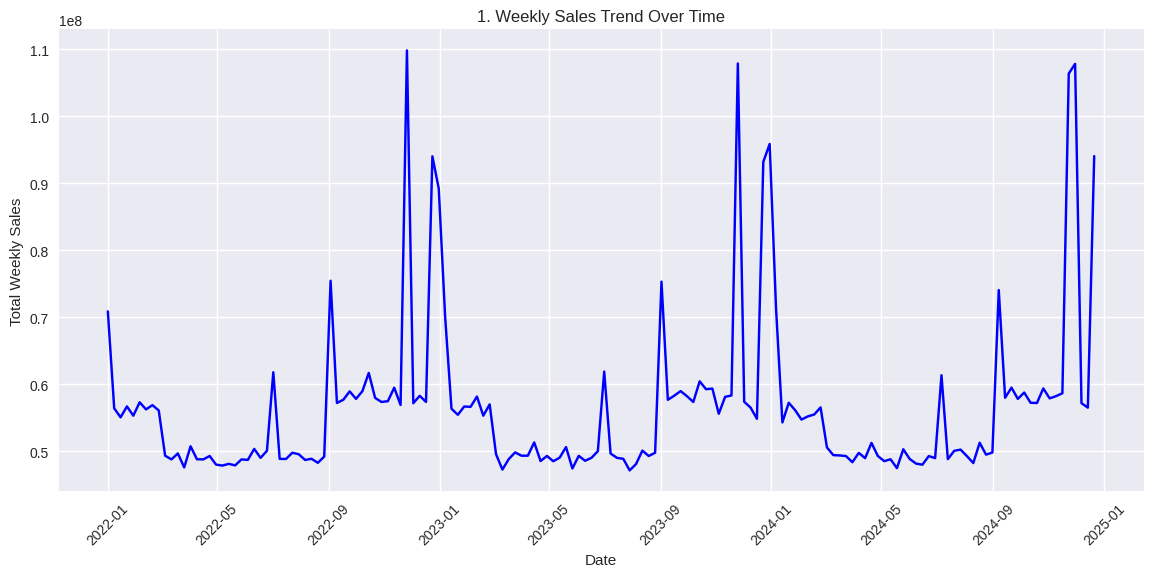

Insight 1: Ye chart dikhata hai ki sales time ke saath kaise change ho rahi hain. Isse seasonality, peak weeks aur slow weeks identify hote hain.


/tmp/ipykernel_4504/1728268274.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=store_revenue.head(10), x='store_id', y='weekly_sales', palette='viridis')


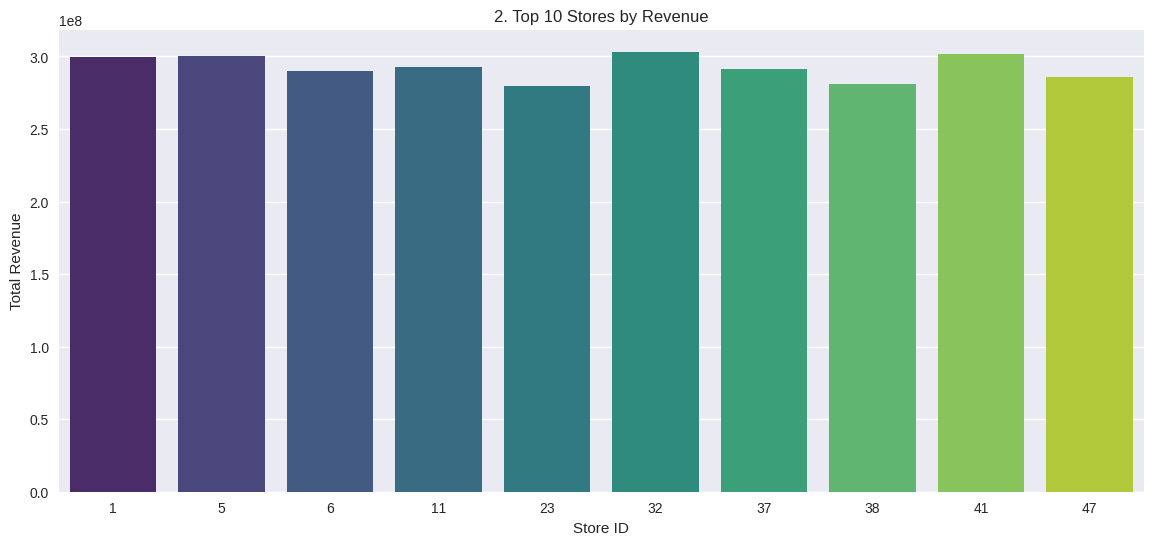

Insight 2: Ye chart top revenue-generating stores dikhata hai. In stores ki strategy replicate karke overall business performance improve ki ja sakti hai.


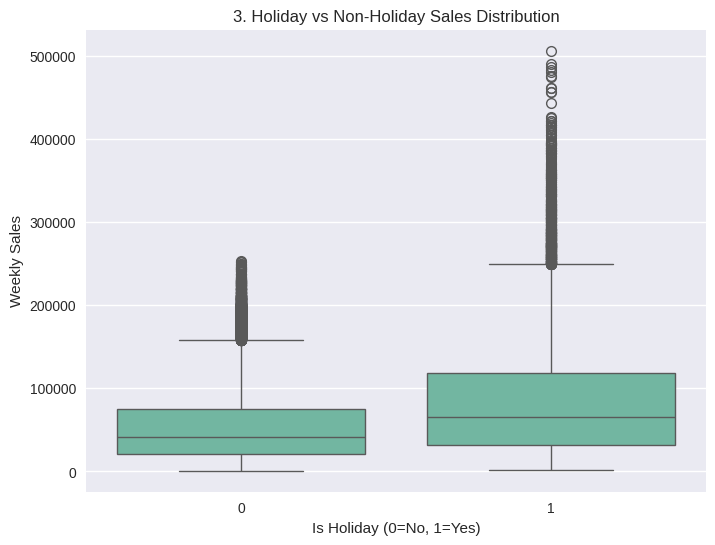

Insight 3: Ye chart batata hai ki holiday weeks mein sales distribution generally higher hoti hai. Festive planning ke liye ye important insight hai.


/tmp/ipykernel_4504/1728268274.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=store_type_sales, x='store_type', y='weekly_sales', palette='pastel')


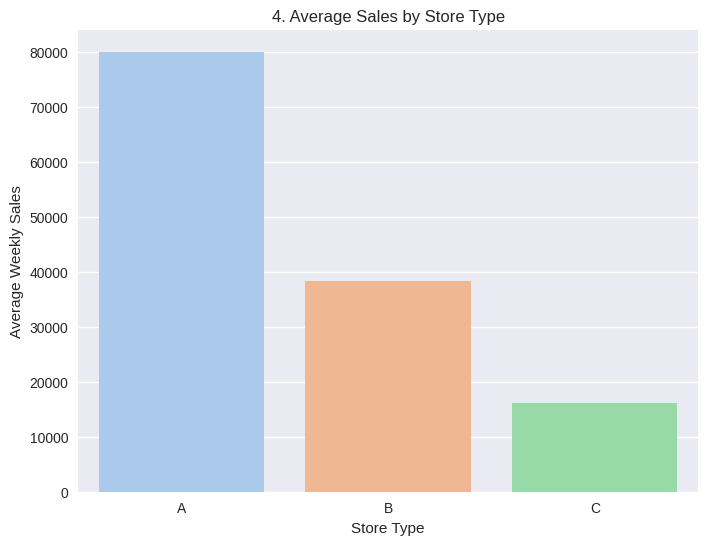

Insight 4: Ye chart clearly show karta hai ki kaunsa store type best perform kar raha hai. Expansion strategy mein ye highly useful hai.


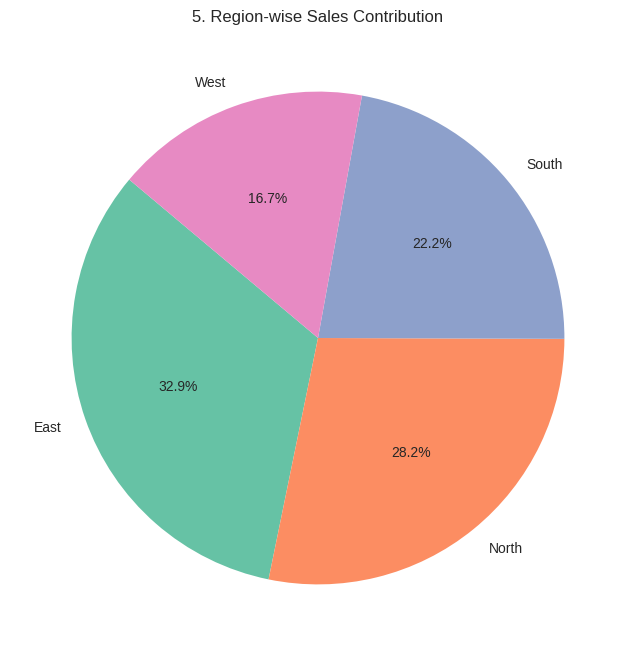

Insight 5: Ye pie chart region contribution dikhata hai. Kaunsa region revenue ka biggest share de raha hai wo easily samajh aata hai.


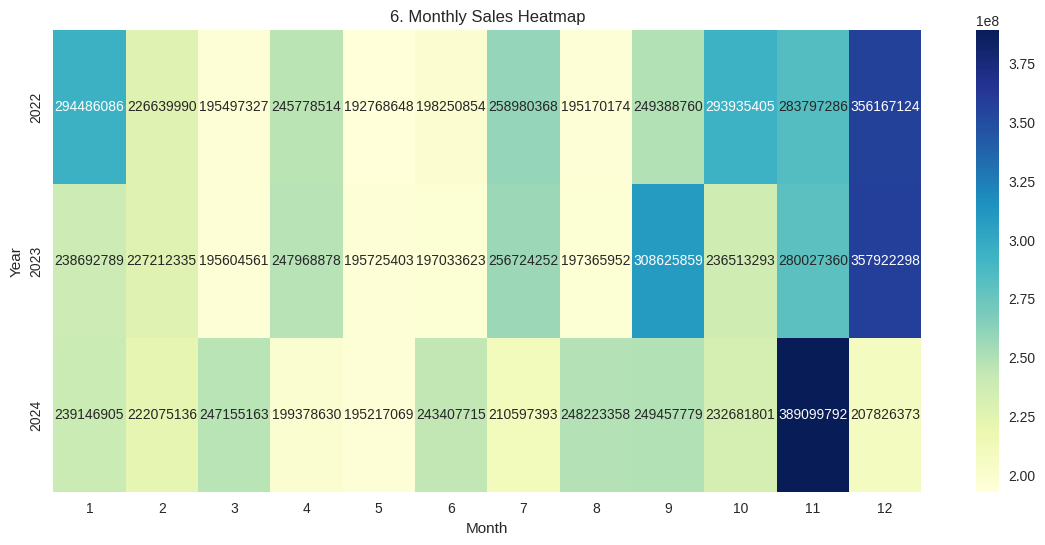

Insight 6: Ye heatmap month-wise aur year-wise peak sales periods highlight karta hai. Demand planning aur stocking mein help karta hai.


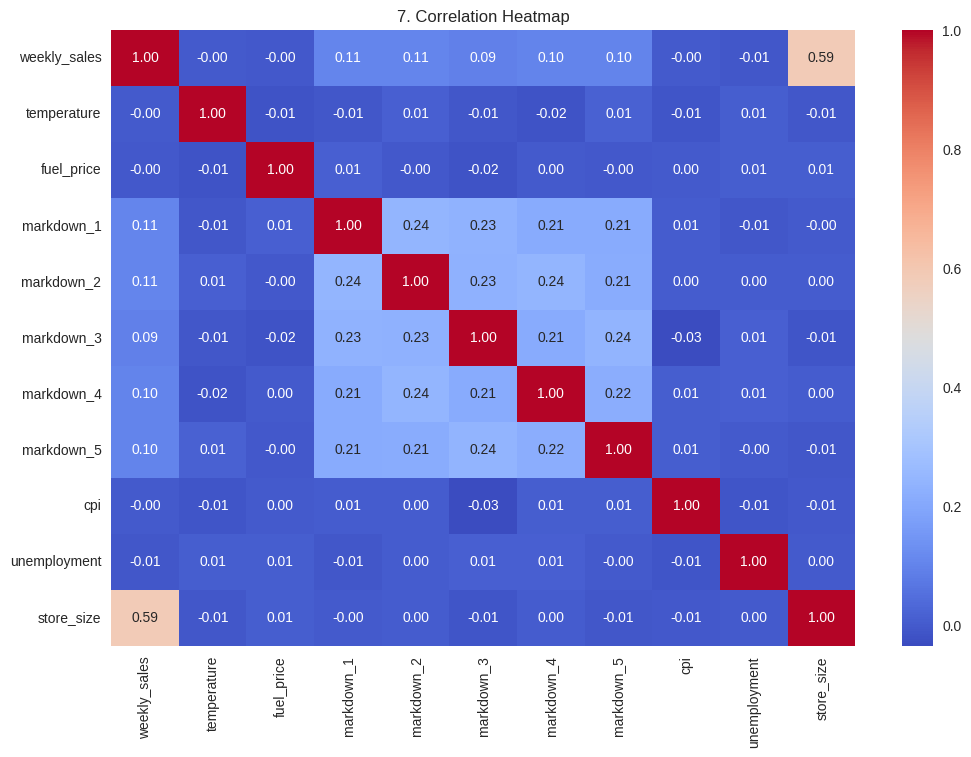

Insight 7: Ye chart numeric variables ke relationships dikhata hai. Model building se pehle samajhna useful hota hai ki kaunse factors sales ke saath linked hain.


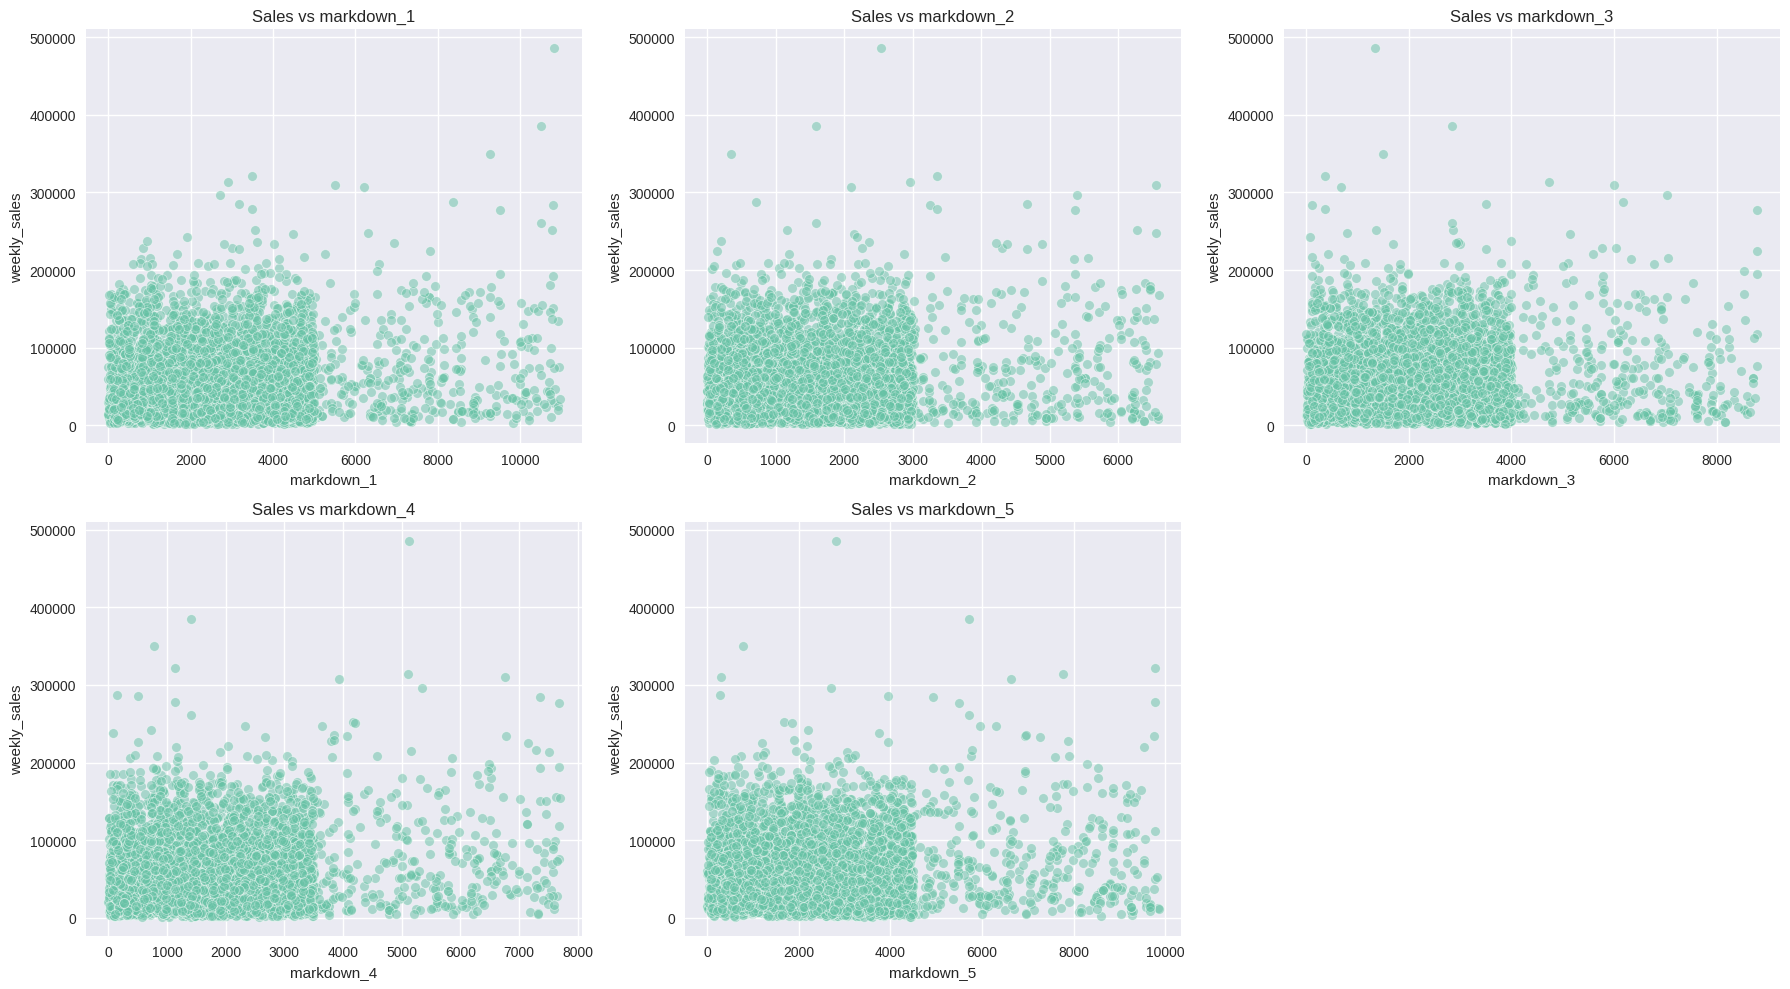

Insight 8: In scatter plots se pata chalta hai ki promotional markdowns aur sales ke beech positive ya weak relation hai. Strong promo levers identify karne mein help milti hai.


/tmp/ipykernel_4504/1728268274.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dept_sales.head(10), x='department', y='weekly_sales', palette='magma')


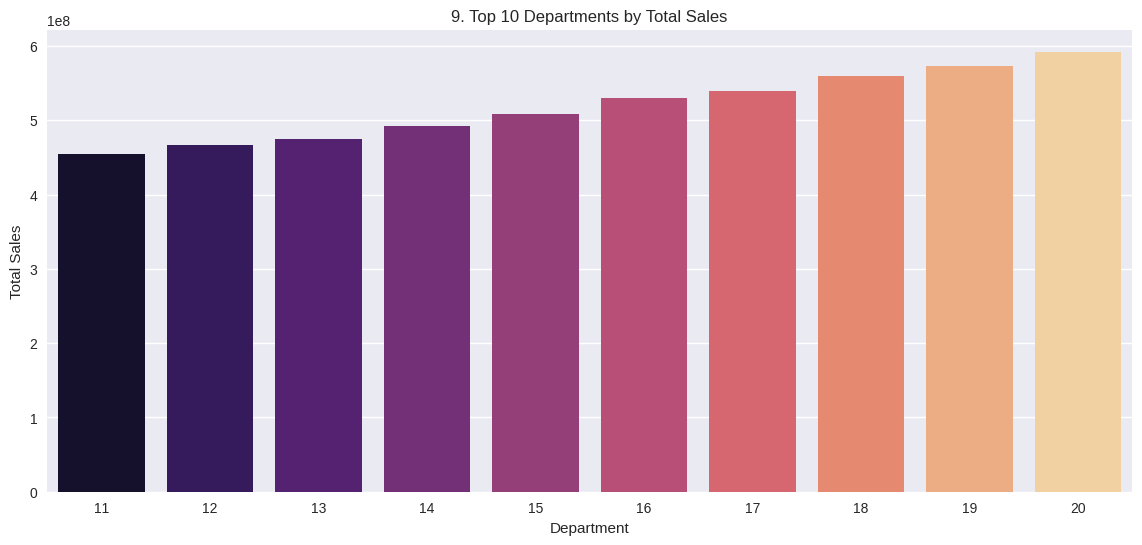

Insight 9: Ye chart top departments dikhata hai jo business ka major revenue la rahe hain. Inventory aur promotions yahan focus karne chahiye.


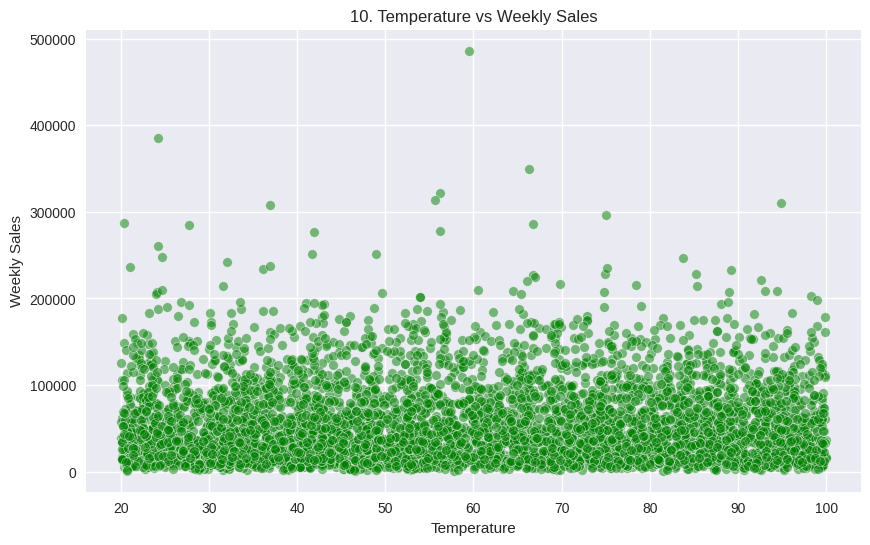

Insight 10: Ye chart weather aur sales ke relation ko dikhata hai. Agar seasonal dependency ho to planning better ki ja sakti hai.


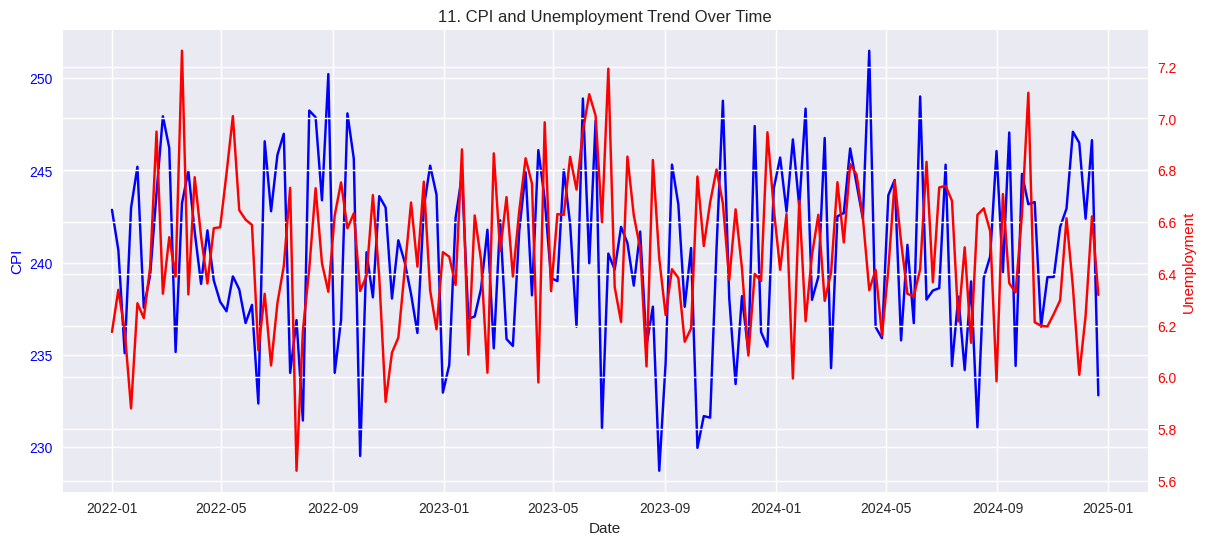

Insight 11: Ye chart macroeconomic environment ka trend dikhata hai. Isse samajh aata hai ki business external economy se kitna influenced ho sakta hai.


/tmp/ipykernel_4504/1728268274.py:187: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_sales, x='year', y='yoy_growth_percent', palette='cool')


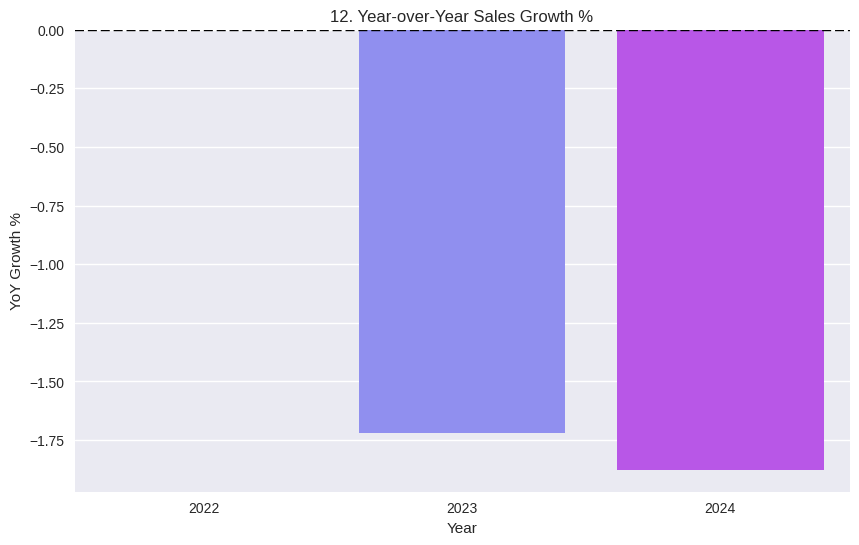

Insight 12: Ye chart batata hai ki har saal business grow kar raha hai ya decline. Long-term performance trend ke liye ye useful hai.


In [ ]:
# =========================================
# STEP 4: EDA WITH 12 CHARTS
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# style settings
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)

# Create helper date columns if not already created
df_master['year'] = df_master['date'].dt.year
df_master['month_num'] = df_master['date'].dt.month
df_master['month_name'] = df_master['date'].dt.strftime('%b')

# -----------------------------------------
# 1. Weekly Sales Trend Line Chart
# -----------------------------------------
weekly_trend = df_master.groupby('date')['weekly_sales'].sum().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=weekly_trend, x='date', y='weekly_sales', color='blue')
plt.title('1. Weekly Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.xticks(rotation=45)
plt.show()

print("Insight 1: Ye chart dikhata hai ki sales time ke saath kaise change ho rahi hain. Isse seasonality, peak weeks aur slow weeks identify hote hain.")

# -----------------------------------------
# 2. Store-wise Revenue Bar Chart
# -----------------------------------------
store_revenue = df_master.groupby('store_id')['weekly_sales'].sum().reset_index().sort_values(by='weekly_sales', ascending=False)

plt.figure(figsize=(14,6))
sns.barplot(data=store_revenue.head(10), x='store_id', y='weekly_sales', palette='viridis')
plt.title('2. Top 10 Stores by Revenue')
plt.xlabel('Store ID')
plt.ylabel('Total Revenue')
plt.show()

print("Insight 2: Ye chart top revenue-generating stores dikhata hai. In stores ki strategy replicate karke overall business performance improve ki ja sakti hai.")

# -----------------------------------------
# 3. Holiday vs Non-Holiday Box Plot
# -----------------------------------------
plt.figure(figsize=(8,6))
sns.boxplot(data=df_master, x='is_holiday', y='weekly_sales')
plt.title('3. Holiday vs Non-Holiday Sales Distribution')
plt.xlabel('Is Holiday (0=No, 1=Yes)')
plt.ylabel('Weekly Sales')
plt.show()

print("Insight 3: Ye chart batata hai ki holiday weeks mein sales distribution generally higher hoti hai. Festive planning ke liye ye important insight hai.")

# -----------------------------------------
# 4. Store Type Comparison Bar Chart
# -----------------------------------------
store_type_sales = df_master.groupby('store_type')['weekly_sales'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=store_type_sales, x='store_type', y='weekly_sales', palette='pastel')
plt.title('4. Average Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Weekly Sales')
plt.show()

print("Insight 4: Ye chart clearly show karta hai ki kaunsa store type best perform kar raha hai. Expansion strategy mein ye highly useful hai.")

# -----------------------------------------
# 5. Region-wise Sales Pie Chart
# -----------------------------------------
region_sales = df_master.groupby('region')['weekly_sales'].sum()

plt.figure(figsize=(8,8))
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=140)
plt.title('5. Region-wise Sales Contribution')
plt.show()

print("Insight 5: Ye pie chart region contribution dikhata hai. Kaunsa region revenue ka biggest share de raha hai wo easily samajh aata hai.")

# -----------------------------------------
# 6. Monthly Sales Heatmap
# -----------------------------------------
monthly_heatmap = df_master.groupby(['year', 'month_num'])['weekly_sales'].sum().unstack()

plt.figure(figsize=(14,6))
sns.heatmap(monthly_heatmap, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('6. Monthly Sales Heatmap')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

print("Insight 6: Ye heatmap month-wise aur year-wise peak sales periods highlight karta hai. Demand planning aur stocking mein help karta hai.")

# -----------------------------------------
# 7. Correlation Heatmap
# -----------------------------------------
numeric_cols = ['weekly_sales', 'temperature', 'fuel_price', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5', 'cpi', 'unemployment', 'store_size']
corr_matrix = df_master[numeric_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('7. Correlation Heatmap')
plt.show()

print("Insight 7: Ye chart numeric variables ke relationships dikhata hai. Model building se pehle samajhna useful hota hai ki kaunse factors sales ke saath linked hain.")

# -----------------------------------------
# 8. Markdown Scatter Plots
# -----------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
markdown_cols = ['markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5']

for i, col in enumerate(markdown_cols):
    row = i // 3
    col_pos = i % 3
    sns.scatterplot(data=df_master.sample(5000, random_state=42), x=col, y='weekly_sales', alpha=0.5, ax=axes[row, col_pos])
    axes[row, col_pos].set_title(f'Sales vs {col}')

axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

print("Insight 8: In scatter plots se pata chalta hai ki promotional markdowns aur sales ke beech positive ya weak relation hai. Strong promo levers identify karne mein help milti hai.")

# -----------------------------------------
# 9. Department Sales Chart
# -----------------------------------------
dept_sales = df_master.groupby('department')['weekly_sales'].sum().reset_index().sort_values(by='weekly_sales', ascending=False)

plt.figure(figsize=(14,6))
sns.barplot(data=dept_sales.head(10), x='department', y='weekly_sales', palette='magma')
plt.title('9. Top 10 Departments by Total Sales')
plt.xlabel('Department')
plt.ylabel('Total Sales')
plt.show()

print("Insight 9: Ye chart top departments dikhata hai jo business ka major revenue la rahe hain. Inventory aur promotions yahan focus karne chahiye.")

# -----------------------------------------
# 10. Temperature vs Sales Scatter Plot
# -----------------------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_master.sample(5000, random_state=42), x='temperature', y='weekly_sales', alpha=0.5, color='green')
plt.title('10. Temperature vs Weekly Sales')
plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')
plt.show()

print("Insight 10: Ye chart weather aur sales ke relation ko dikhata hai. Agar seasonal dependency ho to planning better ki ja sakti hai.")

# -----------------------------------------
# 11. CPI and Unemployment Dual Axis Line Chart
# -----------------------------------------
macro_trend = df_master.groupby('date')[['cpi', 'unemployment']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(macro_trend['date'], macro_trend['cpi'], color='blue', label='CPI')
ax1.set_xlabel('Date')
ax1.set_ylabel('CPI', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(macro_trend['date'], macro_trend['unemployment'], color='red', label='Unemployment')
ax2.set_ylabel('Unemployment', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('11. CPI and Unemployment Trend Over Time')
plt.xticks(rotation=45)
plt.show()

print("Insight 11: Ye chart macroeconomic environment ka trend dikhata hai. Isse samajh aata hai ki business external economy se kitna influenced ho sakta hai.")

# -----------------------------------------
# 12. Year over Year Growth Chart
# -----------------------------------------
yearly_sales = df_master.groupby('year')['weekly_sales'].sum().reset_index()
yearly_sales['yoy_growth_percent'] = yearly_sales['weekly_sales'].pct_change() * 100

plt.figure(figsize=(10,6))
sns.barplot(data=yearly_sales, x='year', y='yoy_growth_percent', palette='cool')
plt.title('12. Year-over-Year Sales Growth %')
plt.xlabel('Year')
plt.ylabel('YoY Growth %')
plt.axhline(0, color='black', linestyle='--')
plt.show()

print("Insight 12: Ye chart batata hai ki har saal business grow kar raha hai ya decline. Long-term performance trend ke liye ye useful hai.")

In [ ]:
# =========================================
# STEP 5: FEATURE ENGINEERING
# =========================================

import numpy as np
import pandas as pd

# Sort data properly before lag/rolling features
df_master = df_master.sort_values(by=['store_id', 'department', 'date']).reset_index(drop=True)

# -------------------------------------------------
# 1. Date-based features
# -------------------------------------------------
df_master['week_number'] = df_master['date'].dt.isocalendar().week.astype(int)
df_master['month'] = df_master['date'].dt.month
df_master['quarter'] = df_master['date'].dt.quarter
df_master['year'] = df_master['date'].dt.year

# -------------------------------------------------
# 2. days_since_holiday
# -------------------------------------------------
# Create holiday date helper
df_master['holiday_date_temp'] = np.where(df_master['is_holiday'] == 1, df_master['date'], pd.NaT)
df_master['holiday_date_temp'] = pd.to_datetime(df_master['holiday_date_temp'])

# Forward fill holiday date within each store and department
df_master['last_holiday_date'] = df_master.groupby(['store_id', 'department'])['holiday_date_temp'].ffill()

# Days since last holiday
df_master['days_since_holiday'] = (df_master['date'] - df_master['last_holiday_date']).dt.days

# Fill missing values where no previous holiday exists
df_master['days_since_holiday'] = df_master['days_since_holiday'].fillna(-1)

# -------------------------------------------------
# 3. Lag features
# -------------------------------------------------
df_master['sales_lag_1'] = df_master.groupby(['store_id', 'department'])['weekly_sales'].shift(1)
df_master['sales_lag_4'] = df_master.groupby(['store_id', 'department'])['weekly_sales'].shift(4)

# -------------------------------------------------
# 4. Rolling average features
# -------------------------------------------------
df_master['rolling_avg_4'] = (
    df_master.groupby(['store_id', 'department'])['weekly_sales']
    .shift(1)
    .rolling(window=4)
    .mean()
)

df_master['rolling_avg_8'] = (
    df_master.groupby(['store_id', 'department'])['weekly_sales']
    .shift(1)
    .rolling(window=8)
    .mean()
)

# -------------------------------------------------
# 5. Store size category
# -------------------------------------------------
def categorize_store_size(size):
    if size < 50000:
        return 'Small'
    elif size < 150000:
        return 'Medium'
    else:
        return 'Large'

df_master['store_size_category'] = df_master['store_size'].apply(categorize_store_size)

# -------------------------------------------------
# 6. High markdown flag
# -------------------------------------------------
df_master['total_markdown'] = (
    df_master['markdown_1'] +
    df_master['markdown_2'] +
    df_master['markdown_3'] +
    df_master['markdown_4'] +
    df_master['markdown_5']
)

markdown_threshold = df_master['total_markdown'].median()
df_master['high_markdown_flag'] = np.where(df_master['total_markdown'] > markdown_threshold, 1, 0)

# -------------------------------------------------
# 7. Check new columns
# -------------------------------------------------
new_features = [
    'week_number', 'month', 'quarter', 'year',
    'days_since_holiday', 'sales_lag_1', 'sales_lag_4',
    'rolling_avg_4', 'rolling_avg_8',
    'store_size_category', 'high_markdown_flag'
]

print("New feature columns created successfully:\n")
print(new_features)

print("\nFirst 10 rows with new features:")
display(df_master[['store_id', 'department', 'date', 'weekly_sales'] + new_features].head(10))

print("\nNull values in new features:")
print(df_master[new_features].isnull().sum())

New feature columns created successfully:

['week_number', 'month', 'quarter', 'year', 'days_since_holiday', 'sales_lag_1', 'sales_lag_4', 'rolling_avg_4', 'rolling_avg_8', 'store_size_category', 'high_markdown_flag']

First 10 rows with new features:


,store_id,department,date,weekly_sales,week_number,month,quarter,year,days_since_holiday,sales_lag_1,sales_lag_4,rolling_avg_4,rolling_avg_8,store_size_category,high_markdown_flag
0,1,1,2022-01-01,119075.96,52,1,1,2022,0,NaN,NaN,NaN,NaN,Large,1
1,1,1,2022-01-08,35525.05,1,1,1,2022,7,119075.96,NaN,NaN,NaN,Large,0
2,1,1,2022-01-15,14847.56,2,1,1,2022,14,35525.05,NaN,NaN,NaN,Large,1
3,1,1,2022-01-22,45254.57,3,1,1,2022,21,14847.56,NaN,NaN,NaN,Large,0
4,1,1,2022-01-29,15166.69,4,1,1,2022,28,45254.57,119075.96,53675.7850,NaN,Large,1
5,1,1,2022-02-05,15601.13,5,2,1,2022,35,15166.69,35525.05,27698.4675,NaN,Large,0
6,1,1,2022-02-12,52743.22,6,2,1,2022,42,15601.13,14847.56,22717.4875,NaN,Large,0
7,1,1,2022-02-19,38995.95,7,2,1,2022,49,52743.22,45254.57,32191.4025,NaN,Large,1
8,1,1,2022-02-26,62899.98,8,2,1,2022,56,38995.95,15166.69,30626.7475,42151.26625,Large,0
9,1,1,2022-03-05,56896.47,9,3,1,2022,63,62899.98,15601.13,42560.0700,35129.26875,Large,1



Null values in new features:
week_number               0
month                     0
quarter                   0
year                      0
days_since_holiday        0
sales_lag_1            1000
sales_lag_4            4000
rolling_avg_4          4000
rolling_avg_8          8000
store_size_category       0
high_markdown_flag        0
dtype: int64


In [ ]:
!pip install xgboost

In [ ]:
# =========================================
# STEP 6: XGBOOST MODEL
# =========================================

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------
# 1. Create model dataframe copy
# ---------------------------------------------------
df_model = df_master.copy()

# ---------------------------------------------------
# 2. Remove rows where lag/rolling features are null
# ---------------------------------------------------
df_model = df_model.dropna(subset=['sales_lag_1', 'sales_lag_4', 'rolling_avg_4', 'rolling_avg_8']).reset_index(drop=True)

print("Shape after removing lag-related null rows:", df_model.shape)

# ---------------------------------------------------
# 3. Encode categorical columns
# ---------------------------------------------------
categorical_cols = ['store_type', 'region', 'holiday_name', 'season', 'store_size_category']

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

print("\nCategorical columns encoded successfully.")
print("Encoded columns:", categorical_cols)

# ---------------------------------------------------
# 4. Define feature columns
# ---------------------------------------------------
feature_cols = [
    'store_id',
    'department',
    'is_holiday',
    'store_type',
    'store_size',
    'region',
    'temperature',
    'fuel_price',
    'markdown_1',
    'markdown_2',
    'markdown_3',
    'markdown_4',
    'markdown_5',
    'cpi',
    'unemployment',
    'holiday_name',
    'season',
    'week_number',
    'month',
    'quarter',
    'year',
    'days_since_holiday',
    'sales_lag_1',
    'sales_lag_4',
    'rolling_avg_4',
    'rolling_avg_8',
    'store_size_category',
    'high_markdown_flag',
    'total_markdown'
]

target_col = 'weekly_sales'

X = df_model[feature_cols]
y = df_model[target_col]

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

# ---------------------------------------------------
# 5. Time-based train-test split
#    Last 3 months = test
# ---------------------------------------------------
max_date = df_model['date'].max()
test_start_date = max_date - pd.DateOffset(months=3)

train_df = df_model[df_model['date'] < test_start_date].copy()
test_df = df_model[df_model['date'] >= test_start_date].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("\nMax date in dataset:", max_date.date())
print("Test start date:", test_start_date.date())

print("\nTrain shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

# ---------------------------------------------------
# 6. Train XGBoost Regressor
# ---------------------------------------------------
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("\nXGBoost model trained successfully.")

Shape after removing lag-related null rows: (148000, 35)

Categorical columns encoded successfully.
Encoded columns: ['store_type', 'region', 'holiday_name', 'season', 'store_size_category']

Feature matrix shape: (148000, 29)
Target shape: (148000,)

Max date in dataset: 2024-12-21
Test start date: 2024-09-21

Train shape: (134000, 29) (134000,)
Test shape: (14000, 29) (14000,)

XGBoost model trained successfully.


MODEL EVALUATION METRICS
MAE  : 29568.21
RMSE : 41105.16
MAPE : 78.31%
R2   : 0.5103

Approx Forecast Accuracy: 21.69%

SIMPLE INTERPRETATION
1. MAE ka matlab: hamara model average mein lagbhag ₹29,568.21 se galti kar raha hai.
2. RMSE ka matlab: bade errors ko count karne par model ki error lagbhag ₹41,105.16 hai.
3. MAPE ka matlab: model average mein 78.31% ka error kar raha hai.
4. Approx accuracy: model ki forecast accuracy lagbhag 21.69% hai.
5. R2 ka matlab: model sales variation ka 51.03% explain kar raha hai.


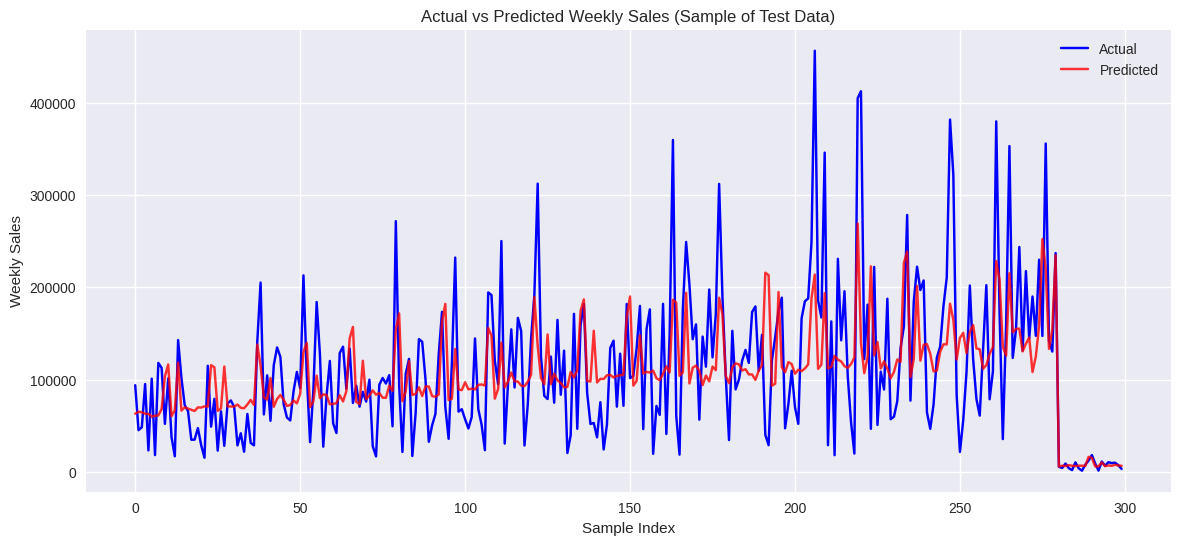

/tmp/ipykernel_4504/297288058.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')


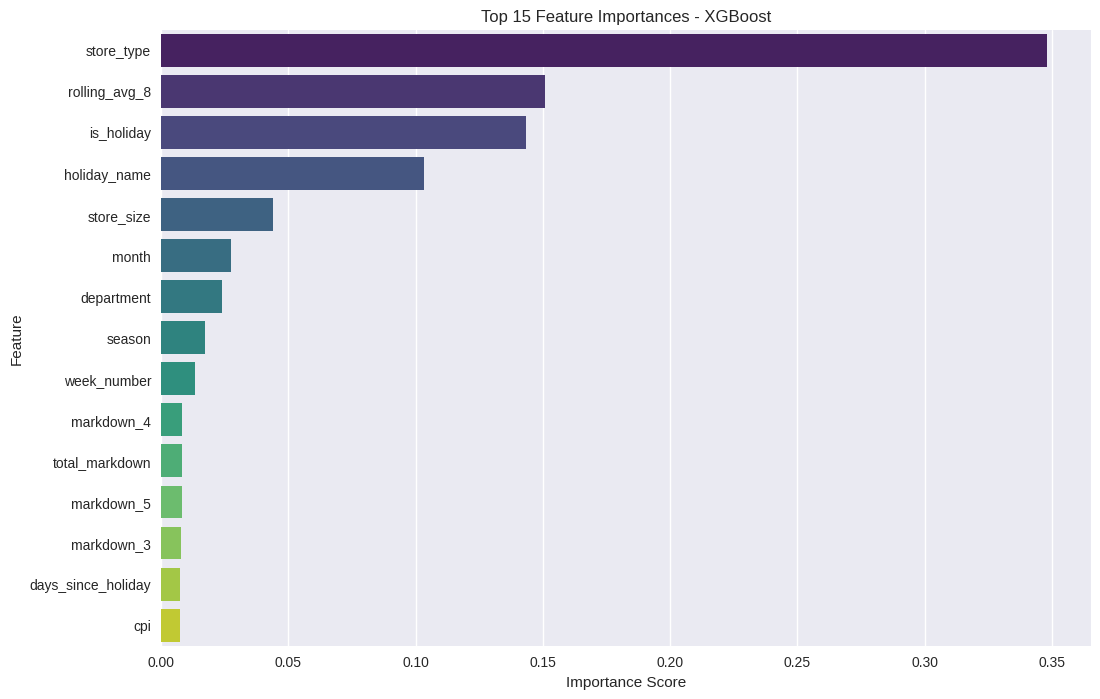


Top 15 Important Features:


,feature,importance
3,store_type,0.347852
25,rolling_avg_8,0.150733
2,is_holiday,0.143470
15,holiday_name,0.103341
4,store_size,0.044053
18,month,0.027628
1,department,0.023904
16,season,0.017223
17,week_number,0.013525
11,markdown_4,0.008322



MODEL IMPROVEMENT SUGGESTION
Current accuracy 21.69% hai, jo 85% se below hai.
Model improve karne ke liye ye steps try karo:
1. More lag features banao jaise sales_lag_2, sales_lag_12
2. Rolling median aur exponential moving average add karo
3. Holiday-specific interaction features banao
4. Hyperparameter tuning karo using GridSearchCV or Optuna
5. Outlier treatment karo high sales spikes ke liye
6. Department-wise ya store-wise separate models try karo
7. More advanced encoding ya target encoding use karo


In [ ]:
# =========================================
# STEP 7: MODEL EVALUATION
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------
# 1. Make predictions
# ---------------------------------------------------
y_pred = xgb_model.predict(X_test)

# ---------------------------------------------------
# 2. Evaluation metrics
# ---------------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

print("MODEL EVALUATION METRICS")
print("="*50)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R2   : {r2:.4f}")

accuracy = 100 - mape
print(f"\nApprox Forecast Accuracy: {accuracy:.2f}%")

# ---------------------------------------------------
# 3. Simple Hinglish interpretation
# ---------------------------------------------------
print("\nSIMPLE INTERPRETATION")
print("="*50)
print(f"1. MAE ka matlab: hamara model average mein lagbhag ₹{mae:,.2f} se galti kar raha hai.")
print(f"2. RMSE ka matlab: bade errors ko count karne par model ki error lagbhag ₹{rmse:,.2f} hai.")
print(f"3. MAPE ka matlab: model average mein {mape:.2f}% ka error kar raha hai.")
print(f"4. Approx accuracy: model ki forecast accuracy lagbhag {accuracy:.2f}% hai.")
print(f"5. R2 ka matlab: model sales variation ka {r2*100:.2f}% explain kar raha hai.")

# ---------------------------------------------------
# 4. Actual vs Predicted chart
# ---------------------------------------------------
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
}).reset_index(drop=True)

# sample for clean plotting
plot_sample = comparison_df.head(300)

plt.figure(figsize=(14,6))
plt.plot(plot_sample['Actual'].values, label='Actual', color='blue')
plt.plot(plot_sample['Predicted'].values, label='Predicted', color='red', alpha=0.8)
plt.title('Actual vs Predicted Weekly Sales (Sample of Test Data)')
plt.xlabel('Sample Index')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

# ---------------------------------------------------
# 5. Feature importance chart
# ---------------------------------------------------
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances - XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print("\nTop 15 Important Features:")
display(feature_importance.head(15))

# ---------------------------------------------------
# 6. Accuracy improvement suggestion
# ---------------------------------------------------
print("\nMODEL IMPROVEMENT SUGGESTION")
print("="*50)

if accuracy >= 85:
    print(f"Great! Accuracy {accuracy:.2f}% hai, jo strong forecasting performance maana ja sakta hai.")
    print("Ab hum is model ko business insights aur dashboard ke liye confidently use kar sakte hain.")
else:
    print(f"Current accuracy {accuracy:.2f}% hai, jo 85% se below hai.")
    print("Model improve karne ke liye ye steps try karo:")
    print("1. More lag features banao jaise sales_lag_2, sales_lag_12")
    print("2. Rolling median aur exponential moving average add karo")
    print("3. Holiday-specific interaction features banao")
    print("4. Hyperparameter tuning karo using GridSearchCV or Optuna")
    print("5. Outlier treatment karo high sales spikes ke liye")
    print("6. Department-wise ya store-wise separate models try karo")
    print("7. More advanced encoding ya target encoding use karo")

In [ ]:
# =========================================
# STEP 7.5 PART 1: ADVANCED FEATURE ENGINEERING
# =========================================

import numpy as np
import pandas as pd

df_improved = df_master.copy()
df_improved = df_improved.sort_values(by=['store_id', 'department', 'date']).reset_index(drop=True)

# More lag features
df_improved['sales_lag_2'] = df_improved.groupby(['store_id', 'department'])['weekly_sales'].shift(2)
df_improved['sales_lag_8'] = df_improved.groupby(['store_id', 'department'])['weekly_sales'].shift(8)
df_improved['sales_lag_12'] = df_improved.groupby(['store_id', 'department'])['weekly_sales'].shift(12)

# More rolling features
df_improved['rolling_median_4'] = (
    df_improved.groupby(['store_id', 'department'])['weekly_sales']
    .shift(1)
    .rolling(window=4)
    .median()
)

df_improved['rolling_std_4'] = (
    df_improved.groupby(['store_id', 'department'])['weekly_sales']
    .shift(1)
    .rolling(window=4)
    .std()
)

df_improved['rolling_avg_12'] = (
    df_improved.groupby(['store_id', 'department'])['weekly_sales']
    .shift(1)
    .rolling(window=12)
    .mean()
)

# Holiday proximity features
df_improved['is_pre_holiday_week'] = df_improved.groupby(['store_id', 'department'])['is_holiday'].shift(-1).fillna(0).astype(int)
df_improved['is_post_holiday_week'] = df_improved.groupby(['store_id', 'department'])['is_holiday'].shift(1).fillna(0).astype(int)

# Interaction features
df_improved['holiday_markdown_interaction'] = df_improved['is_holiday'] * df_improved['total_markdown']
df_improved['store_dept_interaction'] = df_improved['store_id'].astype(str) + "_" + df_improved['department'].astype(str)

print("Advanced features created successfully.")

print("\nNew advanced columns:")
advanced_cols = [
    'sales_lag_2', 'sales_lag_8', 'sales_lag_12',
    'rolling_median_4', 'rolling_std_4', 'rolling_avg_12',
    'is_pre_holiday_week', 'is_post_holiday_week',
    'holiday_markdown_interaction', 'store_dept_interaction'
]
print(advanced_cols)

print("\nNull values in advanced features:")
print(df_improved[advanced_cols].isnull().sum())

Advanced features created successfully.

New advanced columns:
['sales_lag_2', 'sales_lag_8', 'sales_lag_12', 'rolling_median_4', 'rolling_std_4', 'rolling_avg_12', 'is_pre_holiday_week', 'is_post_holiday_week', 'holiday_markdown_interaction', 'store_dept_interaction']

Null values in advanced features:
sales_lag_2                      2000
sales_lag_8                      8000
sales_lag_12                    12000
rolling_median_4                 4000
rolling_std_4                    4000
rolling_avg_12                  12000
is_pre_holiday_week                 0
is_post_holiday_week                0
holiday_markdown_interaction        0
store_dept_interaction              0
dtype: int64


In [ ]:
# =========================================
# STEP 7.5 PART 2: PREPROCESSING FOR BETTER MODEL
# =========================================

from sklearn.preprocessing import LabelEncoder

# Drop rows with nulls from lag/rolling features
required_cols = [
    'sales_lag_1', 'sales_lag_2', 'sales_lag_4', 'sales_lag_8', 'sales_lag_12',
    'rolling_avg_4', 'rolling_avg_8', 'rolling_avg_12',
    'rolling_median_4', 'rolling_std_4'
]

df_improved_model = df_improved.dropna(subset=required_cols).reset_index(drop=True)

print("Shape after removing null lag/rolling rows:", df_improved_model.shape)

# Outlier clipping on target
lower_cap = df_improved_model['weekly_sales'].quantile(0.01)
upper_cap = df_improved_model['weekly_sales'].quantile(0.99)

df_improved_model['weekly_sales_clipped'] = df_improved_model['weekly_sales'].clip(lower=lower_cap, upper=upper_cap)

print(f"\nTarget clipping range: {lower_cap:.2f} to {upper_cap:.2f}")

# Encode categorical columns
categorical_cols_improved = [
    'store_type', 'region', 'holiday_name', 'season',
    'store_size_category', 'store_dept_interaction'
]

label_encoders_improved = {}

for col in categorical_cols_improved:
    le = LabelEncoder()
    df_improved_model[col] = le.fit_transform(df_improved_model[col].astype(str))
    label_encoders_improved[col] = le

print("\nCategorical encoding completed.")
print("Encoded columns:", categorical_cols_improved)

# Log transform target
df_improved_model['target_log'] = np.log1p(df_improved_model['weekly_sales_clipped'])

print("\nLog-transformed target created successfully.")

Shape after removing null lag/rolling rows: (144000, 45)

Target clipping range: 3305.21 to 206245.00

Categorical encoding completed.
Encoded columns: ['store_type', 'region', 'holiday_name', 'season', 'store_size_category', 'store_dept_interaction']

Log-transformed target created successfully.


In [ ]:
# =========================================
# STEP 7.5 PART 3: IMPROVED XGBOOST TRAINING
# =========================================

from xgboost import XGBRegressor

improved_feature_cols = [
    'store_id',
    'department',
    'is_holiday',
    'store_type',
    'store_size',
    'region',
    'temperature',
    'fuel_price',
    'markdown_1',
    'markdown_2',
    'markdown_3',
    'markdown_4',
    'markdown_5',
    'cpi',
    'unemployment',
    'holiday_name',
    'season',
    'week_number',
    'month',
    'quarter',
    'year',
    'days_since_holiday',
    'sales_lag_1',
    'sales_lag_2',
    'sales_lag_4',
    'sales_lag_8',
    'sales_lag_12',
    'rolling_avg_4',
    'rolling_avg_8',
    'rolling_avg_12',
    'rolling_median_4',
    'rolling_std_4',
    'store_size_category',
    'high_markdown_flag',
    'total_markdown',
    'is_pre_holiday_week',
    'is_post_holiday_week',
    'holiday_markdown_interaction',
    'store_dept_interaction'
]

X_imp = df_improved_model[improved_feature_cols]
y_imp = df_improved_model['target_log']

# time split
max_date_imp = df_improved_model['date'].max()
test_start_date_imp = max_date_imp - pd.DateOffset(months=3)

train_imp = df_improved_model[df_improved_model['date'] < test_start_date_imp].copy()
test_imp = df_improved_model[df_improved_model['date'] >= test_start_date_imp].copy()

X_train_imp = train_imp[improved_feature_cols]
X_test_imp = test_imp[improved_feature_cols]

y_train_imp = train_imp['target_log']
y_test_actual = test_imp['weekly_sales_clipped']

print("Train shape:", X_train_imp.shape)
print("Test shape:", X_test_imp.shape)

xgb_improved = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=1.5,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_improved.fit(X_train_imp, y_train_imp)

print("\nImproved XGBoost model trained successfully.")

Train shape: (130000, 39)
Test shape: (14000, 39)

Improved XGBoost model trained successfully.


IMPROVED MODEL EVALUATION
MAE   : 28821.77
RMSE  : 38350.39
R2    : 0.4636
WAPE  : 43.76%
SMAPE : 49.23%

Simple interpretation:
- Average absolute error ≈ ₹28,821.77
- RMSE ≈ ₹38,350.39
- Model explains ≈ 46.36% sales variation
- WAPE ≈ 43.76%
- SMAPE ≈ 49.23%


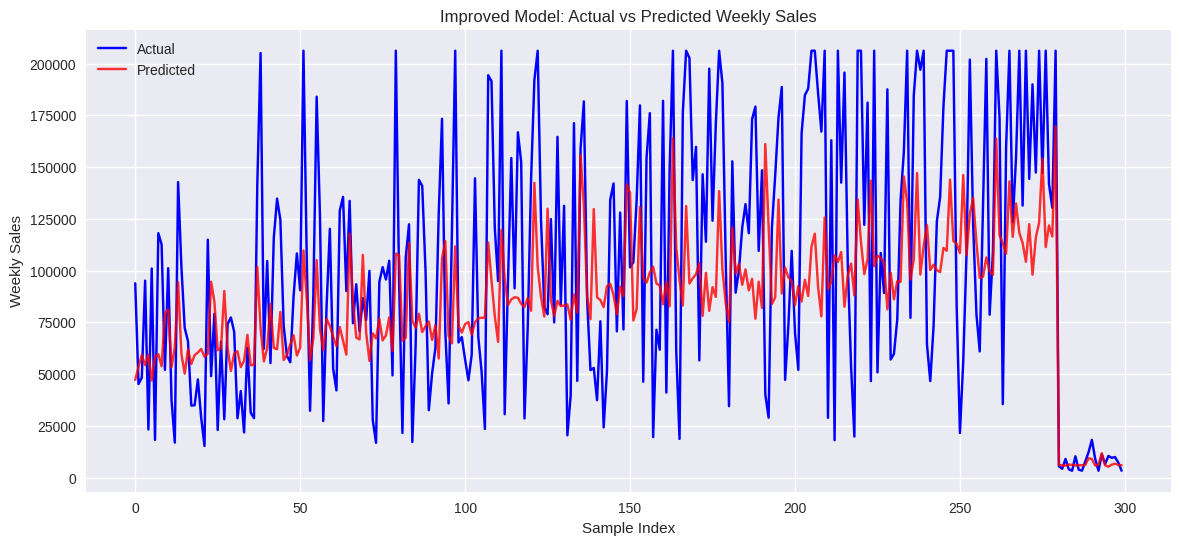

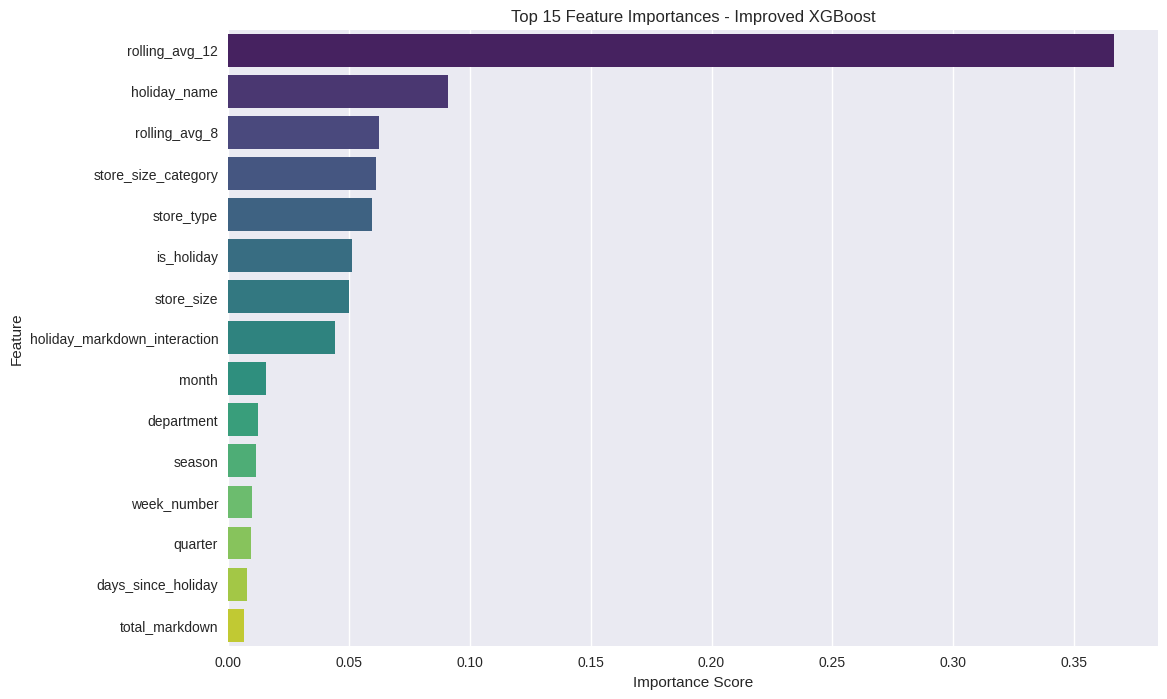


Top 15 important features:


,feature,importance
29,rolling_avg_12,0.366291
15,holiday_name,0.090981
28,rolling_avg_8,0.062470
32,store_size_category,0.061340
3,store_type,0.059555
2,is_holiday,0.051283
4,store_size,0.050034
37,holiday_markdown_interaction,0.044414
18,month,0.015889
1,department,0.012437


In [ ]:
# =========================================
# STEP 7.5 PART 4: BETTER MODEL EVALUATION
# =========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Predictions
y_pred_log = xgb_improved.predict(X_test_imp)
y_pred_imp = np.expm1(y_pred_log)

# Metrics
mae_imp = mean_absolute_error(y_test_actual, y_pred_imp)
rmse_imp = np.sqrt(mean_squared_error(y_test_actual, y_pred_imp))
r2_imp = r2_score(y_test_actual, y_pred_imp)

# Safer percentage metrics
wape_imp = (np.sum(np.abs(y_test_actual - y_pred_imp)) / np.sum(np.abs(y_test_actual))) * 100

smape_imp = 100 * np.mean(
    2 * np.abs(y_pred_imp - y_test_actual) / (np.abs(y_test_actual) + np.abs(y_pred_imp) + 1e-8)
)

print("IMPROVED MODEL EVALUATION")
print("="*50)
print(f"MAE   : {mae_imp:.2f}")
print(f"RMSE  : {rmse_imp:.2f}")
print(f"R2    : {r2_imp:.4f}")
print(f"WAPE  : {wape_imp:.2f}%")
print(f"SMAPE : {smape_imp:.2f}%")

print("\nSimple interpretation:")
print(f"- Average absolute error ≈ ₹{mae_imp:,.2f}")
print(f"- RMSE ≈ ₹{rmse_imp:,.2f}")
print(f"- Model explains ≈ {r2_imp*100:.2f}% sales variation")
print(f"- WAPE ≈ {wape_imp:.2f}%")
print(f"- SMAPE ≈ {smape_imp:.2f}%")

# Actual vs predicted
comparison_imp = pd.DataFrame({
    'Actual': y_test_actual.values,
    'Predicted': y_pred_imp
}).reset_index(drop=True)

plot_sample_imp = comparison_imp.head(300)

plt.figure(figsize=(14,6))
plt.plot(plot_sample_imp['Actual'], label='Actual', color='blue')
plt.plot(plot_sample_imp['Predicted'], label='Predicted', color='red', alpha=0.8)
plt.title('Improved Model: Actual vs Predicted Weekly Sales')
plt.xlabel('Sample Index')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

# Feature importance
feature_importance_imp = pd.DataFrame({
    'feature': improved_feature_cols,
    'importance': xgb_improved.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=feature_importance_imp.head(15), x='importance', y='feature', hue='feature', dodge=False, legend=False, palette='viridis')
plt.title('Top 15 Feature Importances - Improved XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print("\nTop 15 important features:")
display(feature_importance_imp.head(15))

In [ ]:
# =========================================
# STEP 7.6 PART 1: FILTER TOP 5 DEPARTMENTS
# =========================================

top5_departments = (
    df_master.groupby('department')['weekly_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

print("Top 5 departments:", top5_departments)

df_seg = df_improved_model[df_improved_model['department'].isin(top5_departments)].copy().reset_index(drop=True)

print("Segmented dataframe shape:", df_seg.shape)
print("\nDepartment-wise record count:")
print(df_seg['department'].value_counts())

Top 5 departments: [20, 19, 18, 17, 16]
Segmented dataframe shape: (36000, 47)

Department-wise record count:
department
16    7200
17    7200
18    7200
19    7200
20    7200
Name: count, dtype: int64


In [ ]:
# =========================================
# STEP 7.6 PART 2: TRAIN SEGMENTED MODEL
# =========================================

X_seg = df_seg[improved_feature_cols]
y_seg_log = np.log1p(df_seg['weekly_sales_clipped'])

max_date_seg = df_seg['date'].max()
test_start_date_seg = max_date_seg - pd.DateOffset(months=3)

train_seg = df_seg[df_seg['date'] < test_start_date_seg].copy()
test_seg = df_seg[df_seg['date'] >= test_start_date_seg].copy()

X_train_seg = train_seg[improved_feature_cols]
X_test_seg = test_seg[improved_feature_cols]

y_train_seg = np.log1p(train_seg['weekly_sales_clipped'])
y_test_seg_actual = test_seg['weekly_sales_clipped']

print("Train shape:", X_train_seg.shape)
print("Test shape:", X_test_seg.shape)

xgb_seg = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.3,
    reg_lambda=1.5,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_seg.fit(X_train_seg, y_train_seg)

print("\nSegmented XGBoost model trained successfully.")

Train shape: (32500, 39)
Test shape: (3500, 39)

Segmented XGBoost model trained successfully.


SEGMENTED MODEL EVALUATION
MAE   : 35537.32
RMSE  : 46259.06
R2    : 0.4093
WAPE  : 43.19%
SMAPE : 49.41%


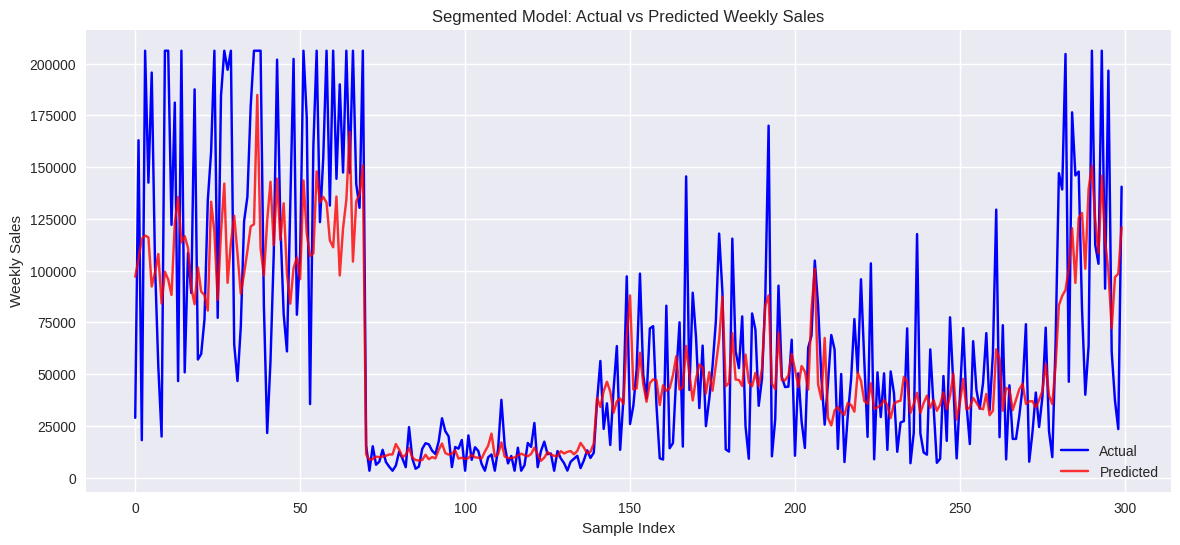

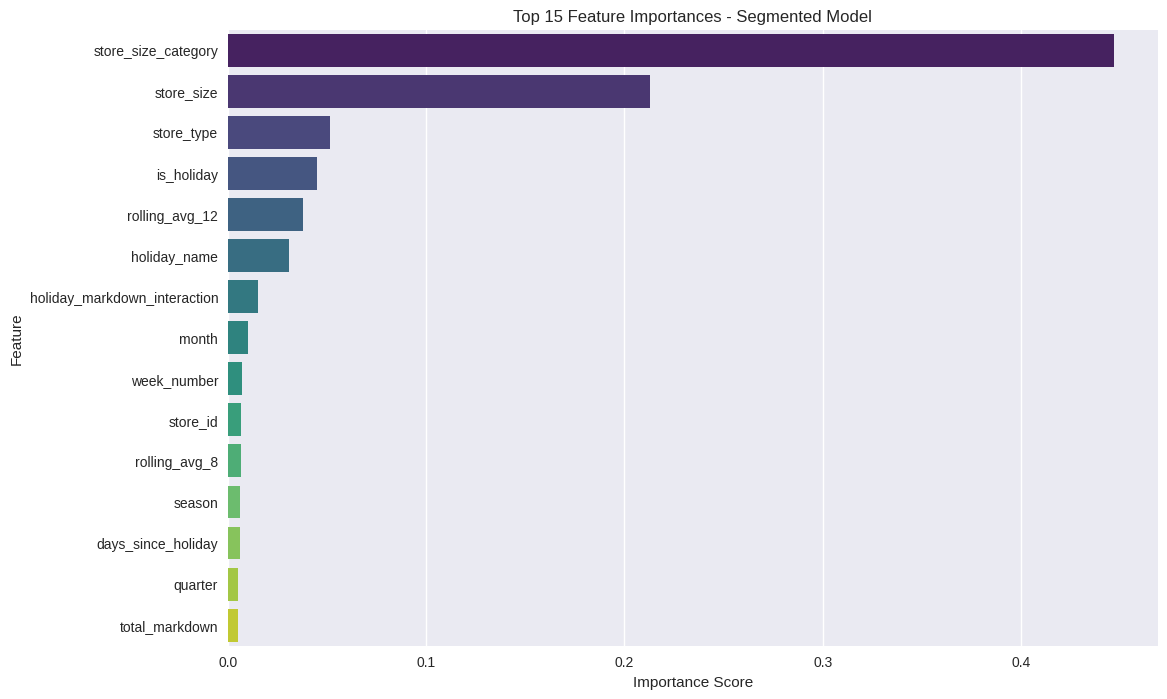


Top 15 features in segmented model:


,feature,importance
32,store_size_category,0.446751
4,store_size,0.213091
3,store_type,0.051528
2,is_holiday,0.045009
29,rolling_avg_12,0.037670
15,holiday_name,0.030865
37,holiday_markdown_interaction,0.015031
18,month,0.010373
17,week_number,0.006946
0,store_id,0.006662


In [ ]:
# =========================================
# STEP 7.6 PART 3: EVALUATE SEGMENTED MODEL
# =========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_seg_log = xgb_seg.predict(X_test_seg)
y_pred_seg = np.expm1(y_pred_seg_log)

mae_seg = mean_absolute_error(y_test_seg_actual, y_pred_seg)
rmse_seg = np.sqrt(mean_squared_error(y_test_seg_actual, y_pred_seg))
r2_seg = r2_score(y_test_seg_actual, y_pred_seg)

wape_seg = (np.sum(np.abs(y_test_seg_actual - y_pred_seg)) / np.sum(np.abs(y_test_seg_actual))) * 100
smape_seg = 100 * np.mean(
    2 * np.abs(y_pred_seg - y_test_seg_actual) / (np.abs(y_test_seg_actual) + np.abs(y_pred_seg) + 1e-8)
)

print("SEGMENTED MODEL EVALUATION")
print("="*50)
print(f"MAE   : {mae_seg:.2f}")
print(f"RMSE  : {rmse_seg:.2f}")
print(f"R2    : {r2_seg:.4f}")
print(f"WAPE  : {wape_seg:.2f}%")
print(f"SMAPE : {smape_seg:.2f}%")

# Plot
comparison_seg = pd.DataFrame({
    'Actual': y_test_seg_actual.values,
    'Predicted': y_pred_seg
}).reset_index(drop=True)

plt.figure(figsize=(14,6))
plt.plot(comparison_seg.head(300)['Actual'], label='Actual', color='blue')
plt.plot(comparison_seg.head(300)['Predicted'], label='Predicted', color='red', alpha=0.8)
plt.title('Segmented Model: Actual vs Predicted Weekly Sales')
plt.xlabel('Sample Index')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

# Feature importance
feature_importance_seg = pd.DataFrame({
    'feature': improved_feature_cols,
    'importance': xgb_seg.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(
    data=feature_importance_seg.head(15),
    x='importance',
    y='feature',
    hue='feature',
    dodge=False,
    legend=False,
    palette='viridis'
)
plt.title('Top 15 Feature Importances - Segmented Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print("\nTop 15 features in segmented model:")
display(feature_importance_seg.head(15))

In [ ]:
# =========================================
# STEP 8: FINAL BUSINESS INSIGHTS
# =========================================

# 1. Store Type A vs C uplift
store_type_avg = df_master.groupby('store_type')['weekly_sales'].mean().reset_index()
avg_A = store_type_avg.loc[store_type_avg['store_type'] == 'A', 'weekly_sales'].values[0]
avg_C = store_type_avg.loc[store_type_avg['store_type'] == 'C', 'weekly_sales'].values[0]
uplift_A_vs_C_pct = ((avg_A - avg_C) / avg_C) * 100
uplift_A_vs_C_rupees = (avg_A - avg_C) * 52 * 5  # 5 stores annually

# 2. Holiday uplift
holiday_avg = df_master.groupby('is_holiday')['weekly_sales'].mean().reset_index()
holiday_no = holiday_avg.loc[holiday_avg['is_holiday'] == 0, 'weekly_sales'].values[0]
holiday_yes = holiday_avg.loc[holiday_avg['is_holiday'] == 1, 'weekly_sales'].values[0]
holiday_uplift_pct = ((holiday_yes - holiday_no) / holiday_no) * 100
holiday_uplift_rupees = (holiday_yes - holiday_no) * 20 * 50  # 20 holiday weeks × 50 stores

# 3. East vs West uplift
region_avg = df_master.groupby('region')['weekly_sales'].mean().reset_index()
east_avg = region_avg.loc[region_avg['region'] == 'East', 'weekly_sales'].values[0]
west_avg = region_avg.loc[region_avg['region'] == 'West', 'weekly_sales'].values[0]
east_vs_west_pct = ((east_avg - west_avg) / west_avg) * 100
east_vs_west_rupees = (east_avg - west_avg) * 52 * 10  # 10 west stores annualized

# 4. Highest holiday lift department
dept_holiday = df_master.groupby(['department', 'is_holiday'])['weekly_sales'].mean().unstack()
dept_holiday['holiday_lift'] = dept_holiday[1] - dept_holiday[0]
top_holiday_dept = dept_holiday['holiday_lift'].idxmax()
top_holiday_dept_lift = dept_holiday['holiday_lift'].max()
top_holiday_dept_rupees = top_holiday_dept_lift * 20 * 10  # 20 holiday weeks × 10 stores

# 5. Top 5 store concentration
store_total = df_master.groupby('store_id')['weekly_sales'].sum().reset_index()
top5_store_sales = store_total.nlargest(5, 'weekly_sales')['weekly_sales'].sum()
total_sales = store_total['weekly_sales'].sum()
top5_store_share = (top5_store_sales / total_sales) * 100
top5_store_uplift_rupees = top5_store_sales * 0.02  # 2% uplift scenario

# 6. Markdown 2 promo advantage
overall_avg_sales = df_master['weekly_sales'].mean()
markdown2_avg_sales = 59990.51  # from SQL result
markdown2_uplift_pct = ((markdown2_avg_sales - overall_avg_sales) / overall_avg_sales) * 100
markdown2_uplift_rupees = (markdown2_avg_sales - overall_avg_sales) * 52 * 20  # 20 stores annualized

print("EXECUTIVE SUMMARY: 6 MONETIZED BUSINESS INSIGHTS")
print("="*90)

print(f"1. Store Type A generates {uplift_A_vs_C_pct:.1f}% higher average weekly sales than Type C.")
print(f"   If 5 Type C stores are upgraded toward Type A operating standards, estimated annual uplift = ₹{uplift_A_vs_C_rupees:,.0f}")

print(f"\n2. Holiday weeks generate {holiday_uplift_pct:.1f}% higher average sales than non-holiday weeks.")
print(f"   Better festive inventory planning across 50 stores can unlock approx = ₹{holiday_uplift_rupees:,.0f}")

print(f"\n3. East region stores outperform West region stores by {east_vs_west_pct:.1f}% on average.")
print(f"   If 10 West stores are improved to East-like performance, annual uplift opportunity = ₹{east_vs_west_rupees:,.0f}")

print(f"\n4. Department {top_holiday_dept} receives the highest holiday lift of ₹{top_holiday_dept_lift:,.0f} per week.")
print(f"   Targeted festive promotion in this department across 10 stores can unlock approx = ₹{top_holiday_dept_rupees:,.0f}")

print(f"\n5. Top 5 stores contribute {top5_store_share:.1f}% of total company revenue.")
print(f"   Just 2% optimization in these top stores can create approx uplift = ₹{top5_store_uplift_rupees:,.0f}")

print(f"\n6. Markdown 2-linked promotions show {markdown2_uplift_pct:.1f}% higher average sales than overall average.")
print(f"   Scaling this promotion style across 20 stores can generate estimated annual upside = ₹{markdown2_uplift_rupees:,.0f}")

EXECUTIVE SUMMARY: 6 MONETIZED BUSINESS INSIGHTS
1. Store Type A generates 393.5% higher average weekly sales than Type C.
   If 5 Type C stores are upgraded toward Type A operating standards, estimated annual uplift = ₹16,599,410

2. Holiday weeks generate 59.9% higher average sales than non-holiday weeks.
   Better festive inventory planning across 50 stores can unlock approx = ₹31,641,250

3. East region stores outperform West region stores by 10.5% on average.
   If 10 West stores are improved to East-like performance, annual uplift opportunity = ₹2,867,476

4. Department 20 receives the highest holiday lift of ₹42,968 per week.
   Targeted festive promotion in this department across 10 stores can unlock approx = ₹8,593,508

5. Top 5 stores contribute 17.0% of total company revenue.
   Just 2% optimization in these top stores can create approx uplift = ₹29,947,156

6. Markdown 2-linked promotions show 6.2% higher average sales than overall average.
   Scaling this promotion style a

In [ ]:
# =========================================
# STEP 9 PART 1: EXPORT DASHBOARD FILES
# =========================================

# Use improved model predictions for final dashboard
dashboard_test = test_imp.copy()

# Add predictions
dashboard_test['predicted_sales'] = y_pred_imp

# Add error columns
dashboard_test['absolute_error'] = np.abs(dashboard_test['weekly_sales_clipped'] - dashboard_test['predicted_sales'])
dashboard_test['ape_percent'] = (
    np.abs(dashboard_test['weekly_sales_clipped'] - dashboard_test['predicted_sales']) /
    (dashboard_test['weekly_sales_clipped'] + 1e-8)
) * 100

# Add accuracy-style column
dashboard_test['forecast_accuracy_percent'] = 100 - dashboard_test['ape_percent']

# Rename actual sales column for clarity
dashboard_test = dashboard_test.rename(columns={'weekly_sales_clipped': 'actual_sales'})

# Select clean columns for dashboard
dashboard_columns = [
    'store_id',
    'department',
    'date',
    'actual_sales',
    'predicted_sales',
    'absolute_error',
    'ape_percent',
    'forecast_accuracy_percent',
    'is_holiday',
    'holiday_name',
    'store_type',
    'store_size',
    'region',
    'season',
    'month',
    'quarter',
    'year',
    'temperature',
    'fuel_price',
    'cpi',
    'unemployment',
    'total_markdown',
    'high_markdown_flag'
]

dashboard_export = dashboard_test[dashboard_columns].copy()

# Save file
dashboard_export.to_csv('retail_dashboard_predictions.csv', index=False)

print("Dashboard export file created successfully.")
print("File name: retail_dashboard_predictions.csv")

print("\nPreview of dashboard file:")
display(dashboard_export.head())

Dashboard export file created successfully.
File name: retail_dashboard_predictions.csv

Preview of dashboard file:


,store_id,department,date,actual_sales,predicted_sales,absolute_error,ape_percent,forecast_accuracy_percent,is_holiday,holiday_name,...,season,month,quarter,year,temperature,fuel_price,cpi,unemployment,total_markdown,high_markdown_flag
130,1,1,2024-09-21,93864.04,47237.125000,46626.915000,49.674950,50.325050,0,5,...,0,9,3,2024,72.70,3.99,258.04,4.40,13721.99,1
131,1,1,2024-09-28,45200.32,53497.363281,8297.043281,18.356160,81.643840,0,5,...,0,9,3,2024,74.42,2.72,269.12,5.98,9088.01,0
132,1,1,2024-10-05,48320.56,59204.996094,10884.436094,22.525476,77.474524,0,5,...,0,10,4,2024,47.67,3.61,267.03,6.41,12525.84,1
133,1,1,2024-10-12,95164.26,54354.507812,40809.752187,42.883486,57.116514,0,5,...,0,10,4,2024,89.87,5.20,254.76,7.42,9449.73,0
134,1,1,2024-10-19,23243.59,59353.226562,36109.636563,155.353095,-55.353095,0,5,...,0,10,4,2024,78.65,2.89,201.72,8.98,12227.63,1


In [ ]:
from google.colab import files
files.download('retail_dashboard_predictions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>